In [43]:
#Assignment 3
# ---------------------------
# 1. Import Libraries
# ---------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML & Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis




In [6]:
# ---------------------------
# 2. Load Dataset
# ---------------------------
data = pd.read_csv("Churn_Modelling.csv")

In [7]:
# ---------------------------
# 3. Basic EDA
# ---------------------------
print(data.head())
print(data.info())
print(data.describe())

   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63       0  
4         790

In [8]:
# ---------------------------
# 4. Feature & Target Separation
# ---------------------------
X = data.drop(['RowNumber', 'CustomerId', 'Surname', 'Exited'], axis=1)
y = data['Exited']

# Encode categorical variables
X = pd.get_dummies(X, drop_first=True)

In [9]:
# ---------------------------
# 5. Train-Test Split
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
# ---------------------------
# 6. Normalize Data
# ---------------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 780us/step - accuracy: 0.8635 - loss: 0.3300
Neural Network Accuracy: 0.8635
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 527us/step
Neural Network Confusion Matrix:
 [[1554   53]
 [ 220  173]]
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 303us/step


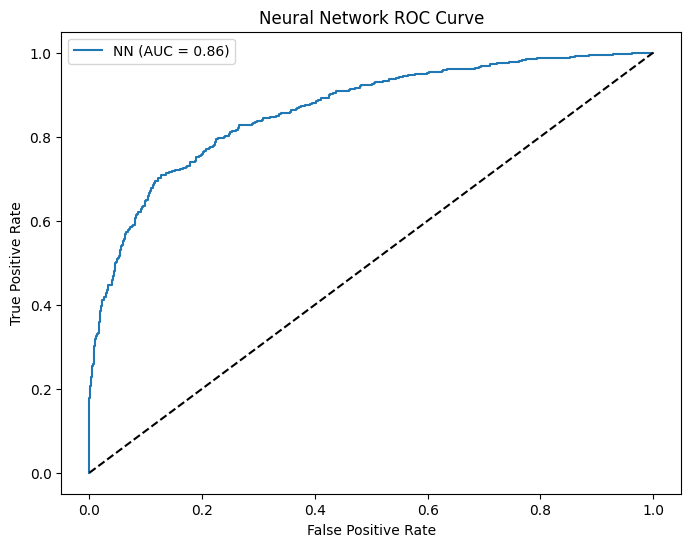

In [11]:
# ---------------------------
# 7. Neural Network (Optional)
# ---------------------------
if tf_available:
    nn_model = Sequential()
    nn_model.add(Dense(32, input_dim=X_train.shape[1], activation='relu'))
    nn_model.add(Dropout(0.2))
    nn_model.add(Dense(16, activation='relu'))
    nn_model.add(Dense(1, activation='sigmoid'))

    nn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    history = nn_model.fit(X_train, y_train, validation_split=0.2, epochs=50, batch_size=32, verbose=0)

    # Evaluate
    loss, accuracy = nn_model.evaluate(X_test, y_test)
    print(f"Neural Network Accuracy: {accuracy:.4f}")

    # Confusion Matrix
    y_pred_nn = (nn_model.predict(X_test) > 0.5).astype(int)
    cm = confusion_matrix(y_test, y_pred_nn)
    print("Neural Network Confusion Matrix:\n", cm)

    # ROC & AUC
    y_prob_nn = nn_model.predict(X_test).ravel()
    fpr, tpr, thresholds = roc_curve(y_test, y_prob_nn)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(8,6))
    plt.plot(fpr, tpr, label=f'NN (AUC = {roc_auc:.2f})')
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Neural Network ROC Curve')
    plt.legend()
    plt.show()


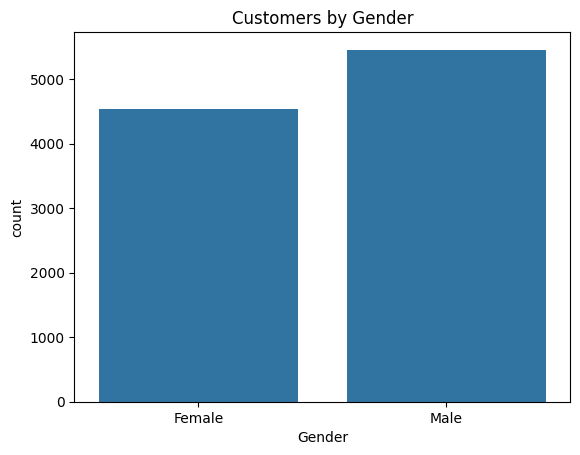

In [13]:
# ---------------------------
# 8. Exploratory Data Analysis (EDA) Plots
# ---------------------------

# Gender distribution
sns.countplot(x='Gender', data=data)
plt.title('Customers by Gender')
plt.show()

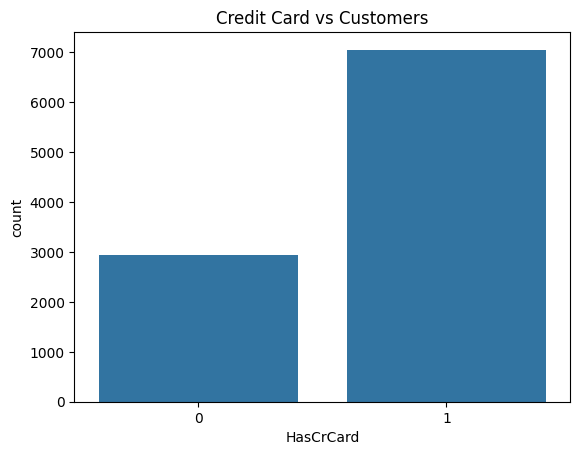

In [14]:
# Credit Card ownership
sns.countplot(x='HasCrCard', data=data)
plt.title('Credit Card vs Customers')
plt.show()

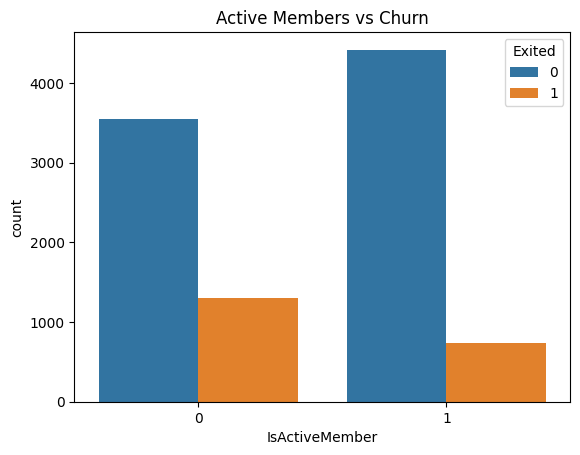

In [15]:
# Active member vs Churn
sns.countplot(x='IsActiveMember', hue='Exited', data=data)
plt.title('Active Members vs Churn')
plt.show()

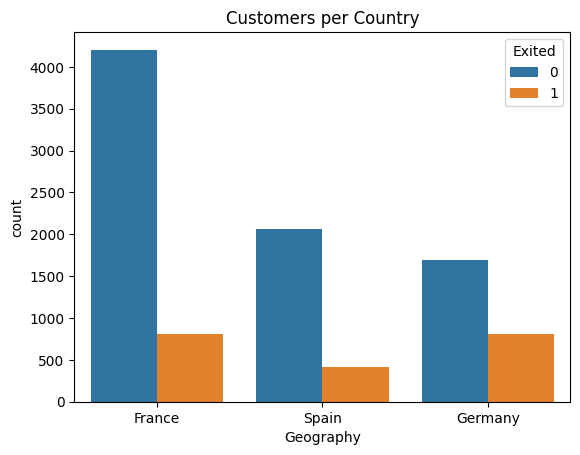

In [16]:
# Customers per country
sns.countplot(x='Geography', hue='Exited', data=data)
plt.title('Customers per Country')
plt.show()

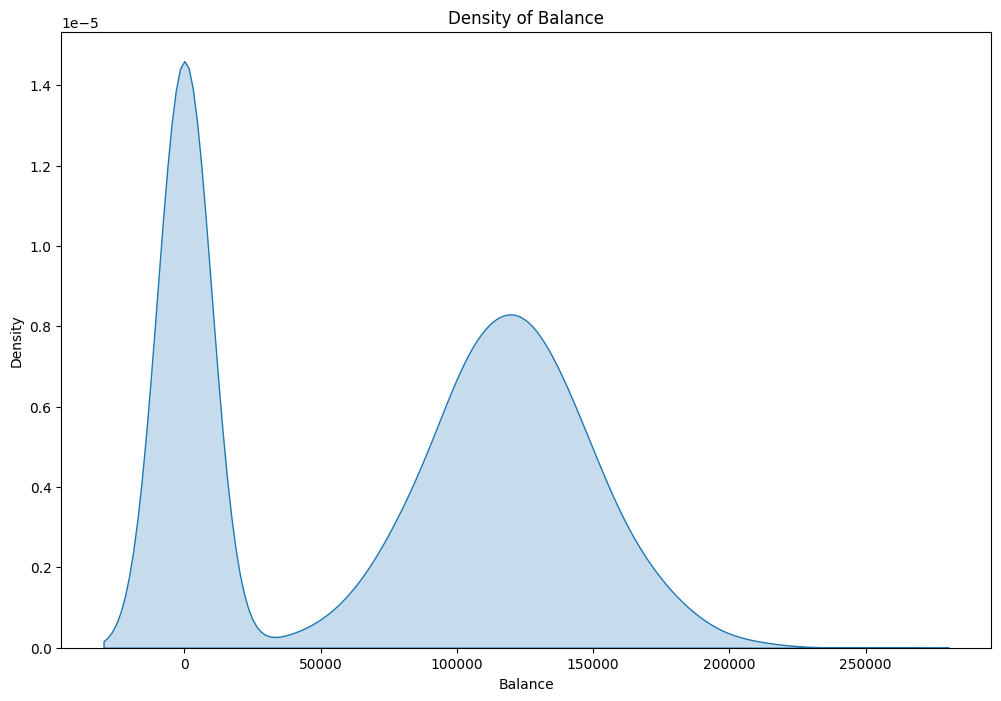

In [17]:
# Density plots
plt.figure(figsize=(12,8))
sns.kdeplot(data['Balance'], fill=True)
plt.title('Density of Balance')
plt.show()

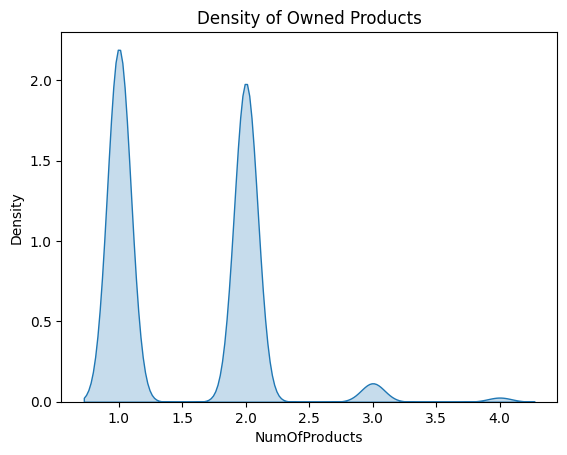

In [18]:
sns.kdeplot(data['NumOfProducts'], fill=True)
plt.title('Density of Owned Products')
plt.show()


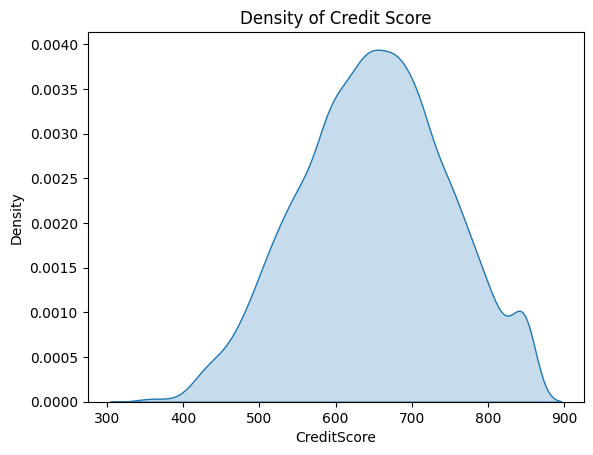

In [19]:
sns.kdeplot(data['CreditScore'], fill=True)
plt.title('Density of Credit Score')
plt.show()

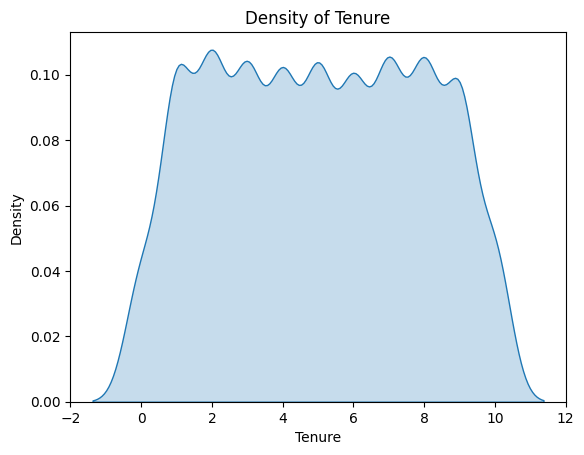

In [20]:
sns.kdeplot(data['Tenure'], fill=True)
plt.title('Density of Tenure')
plt.show()

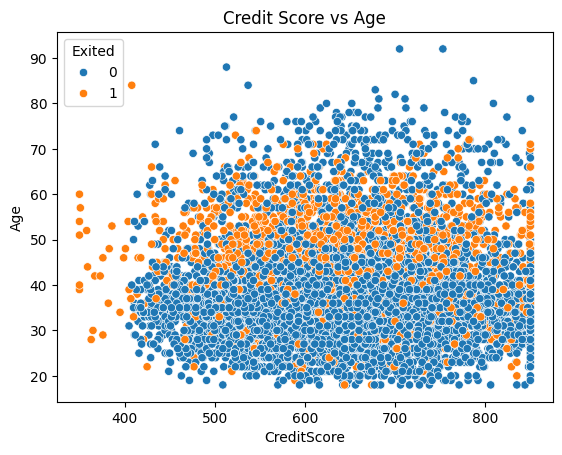

In [21]:
# Credit Score vs Age
sns.scatterplot(x='CreditScore', y='Age', hue='Exited', data=data)
plt.title('Credit Score vs Age')
plt.show()

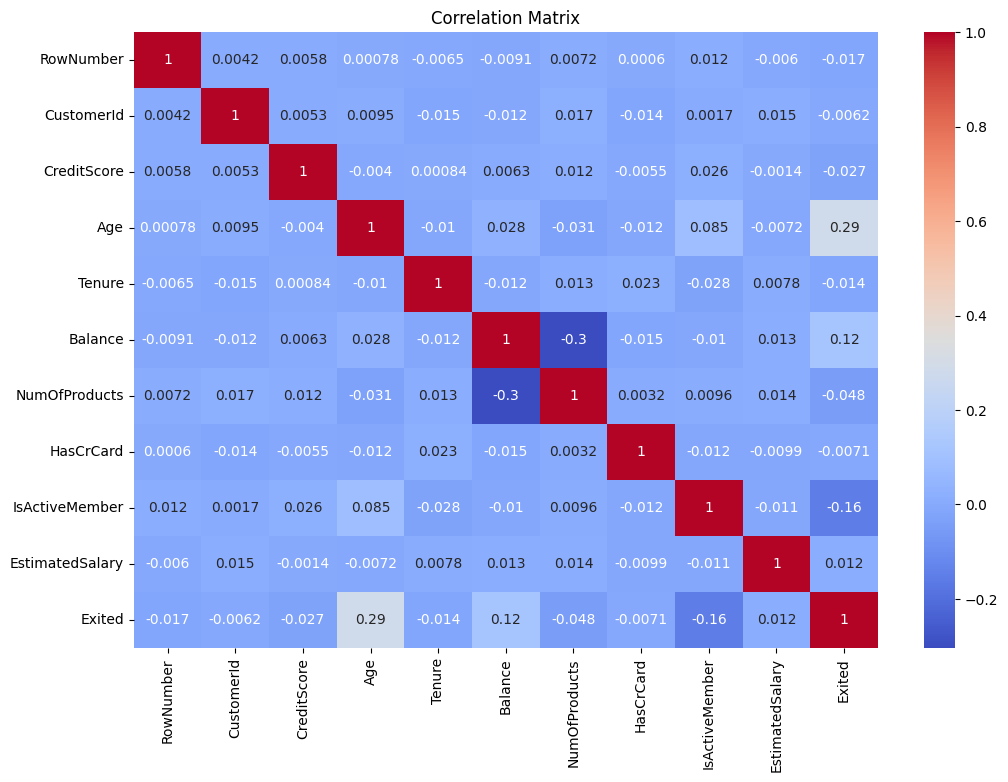

In [24]:
# Select only numeric columns
numeric_data = data.select_dtypes(include=np.number)

# Correlation matrix
plt.figure(figsize=(12,8))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt

# Train model
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

# Predict
y_pred_rf = rf.predict(X_test)
acc = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {acc:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)
print(f"Random Forest Confusion Matrix:\n{cm}")


Random Forest Accuracy: 0.8715
Random Forest Confusion Matrix:
[[1549   58]
 [ 199  194]]


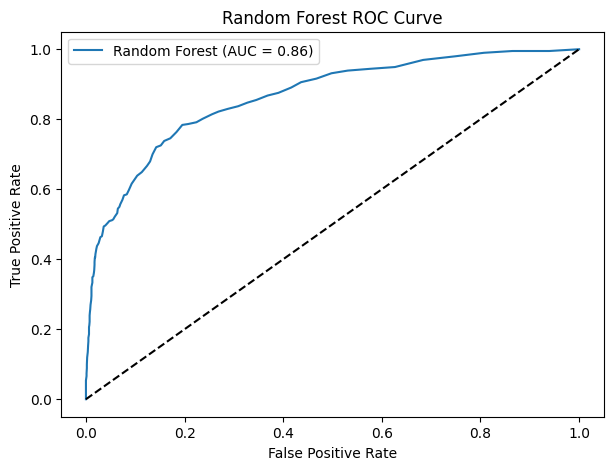

In [28]:
# ROC & AUC
y_prob_rf = rf.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {roc_auc:.2f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest ROC Curve')
plt.legend()
plt.show()


In [29]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)
acc = accuracy_score(y_test, y_pred_knn)
print(f"KNN Accuracy: {acc:.4f}")

cm = confusion_matrix(y_test, y_pred_knn)
print(f"KNN Confusion Matrix:\n{cm}")


KNN Accuracy: 0.8300
KNN Confusion Matrix:
[[1514   93]
 [ 247  146]]


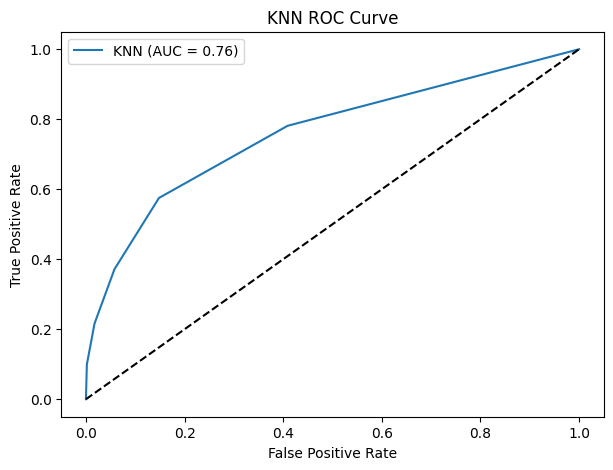

In [30]:
y_prob_knn = knn.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob_knn)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'KNN (AUC = {roc_auc:.2f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('KNN ROC Curve')
plt.legend()
plt.show()


In [31]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
acc = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Accuracy: {acc:.4f}")

cm = confusion_matrix(y_test, y_pred_lr)
print(f"Logistic Regression Confusion Matrix:\n{cm}")


Logistic Regression Accuracy: 0.8110
Logistic Regression Confusion Matrix:
[[1543   64]
 [ 314   79]]


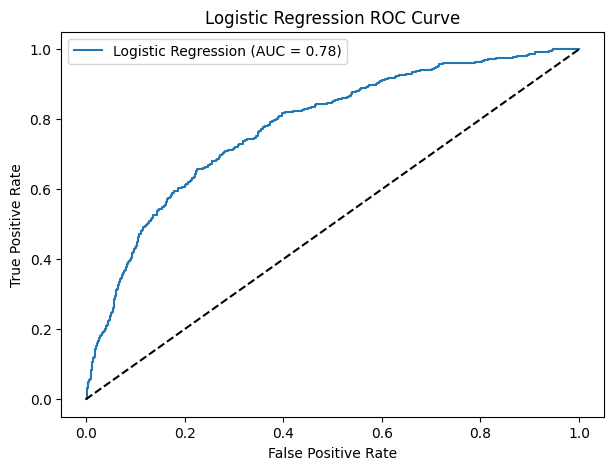

In [32]:
y_prob_lr = lr.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc:.2f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression ROC Curve')
plt.legend()
plt.show()


In [33]:
from sklearn.svm import SVC

svm = SVC(probability=True)
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)
acc = accuracy_score(y_test, y_pred_svm)
print(f"SVM Accuracy: {acc:.4f}")

cm = confusion_matrix(y_test, y_pred_svm)
print(f"SVM Confusion Matrix:\n{cm}")


SVM Accuracy: 0.8560
SVM Confusion Matrix:
[[1562   45]
 [ 243  150]]


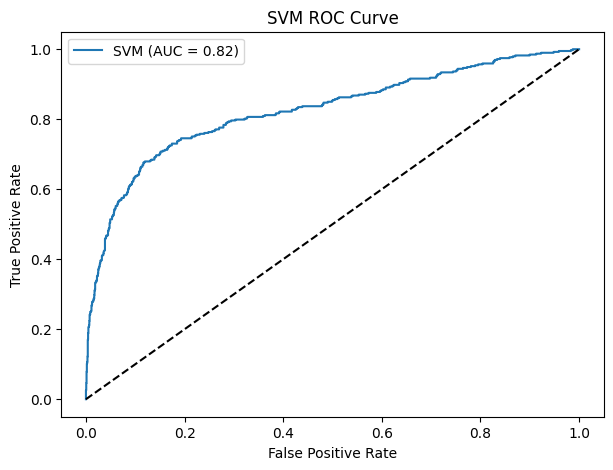

In [34]:
y_prob_svm = svm.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob_svm)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'SVM (AUC = {roc_auc:.2f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('SVM ROC Curve')
plt.legend()
plt.show()


In [35]:
from xgboost import XGBClassifier

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
acc = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Accuracy: {acc:.4f}")

cm = confusion_matrix(y_test, y_pred_xgb)
print(f"XGBoost Confusion Matrix:\n{cm}")


XGBoost Accuracy: 0.8695
XGBoost Confusion Matrix:
[[1521   86]
 [ 175  218]]


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [01:49:59] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


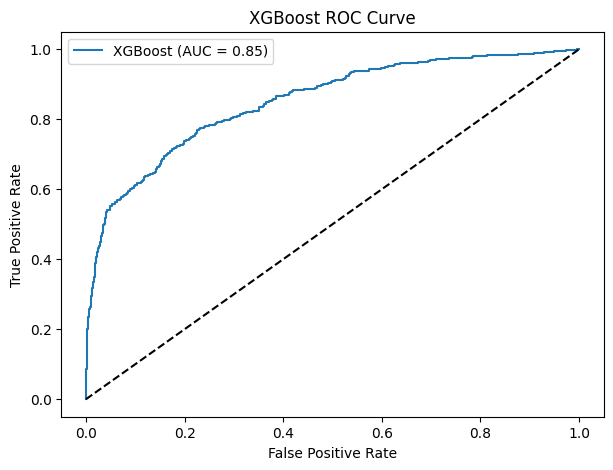

In [36]:
y_prob_xgb = xgb.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob_xgb)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc:.2f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost ROC Curve')
plt.legend()
plt.show()


In [37]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)
acc = accuracy_score(y_test, y_pred_nb)
print(f"Naive Bayes Accuracy: {acc:.4f}")

cm = confusion_matrix(y_test, y_pred_nb)
print(f"Naive Bayes Confusion Matrix:\n{cm}")


Naive Bayes Accuracy: 0.8335
Naive Bayes Confusion Matrix:
[[1526   81]
 [ 252  141]]


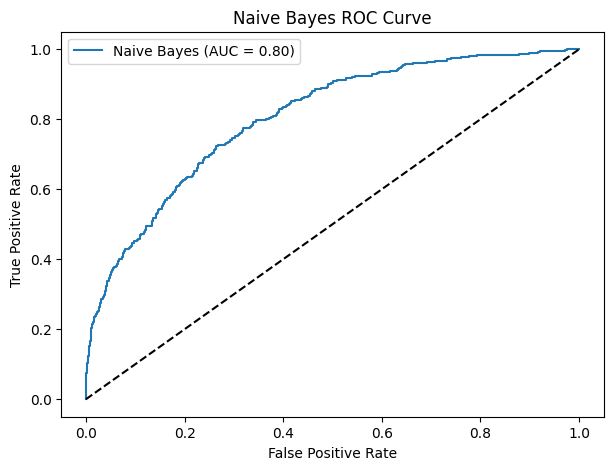

In [38]:
y_prob_nb = nb.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob_nb)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'Naive Bayes (AUC = {roc_auc:.2f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Naive Bayes ROC Curve')
plt.legend()
plt.show()


In [39]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

y_pred_lda = lda.predict(X_test)
acc = accuracy_score(y_test, y_pred_lda)
print(f"LDA Accuracy: {acc:.4f}")

cm = confusion_matrix(y_test, y_pred_lda)
print(f"LDA Confusion Matrix:\n{cm}")


LDA Accuracy: 0.8085
LDA Confusion Matrix:
[[1529   78]
 [ 305   88]]


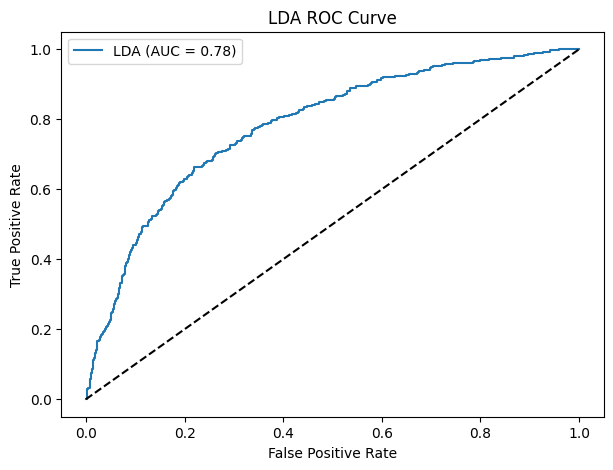

In [40]:
y_prob_lda = lda.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob_lda)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'LDA (AUC = {roc_auc:.2f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('LDA ROC Curve')
plt.legend()
plt.show()


In [41]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train, y_train)

y_pred_qda = qda.predict(X_test)
acc = accuracy_score(y_test, y_pred_qda)
print(f"QDA Accuracy: {acc:.4f}")

cm = confusion_matrix(y_test, y_pred_qda)
print(f"QDA Confusion Matrix:\n{cm}")


QDA Accuracy: 0.8370
QDA Confusion Matrix:
[[1524   83]
 [ 243  150]]


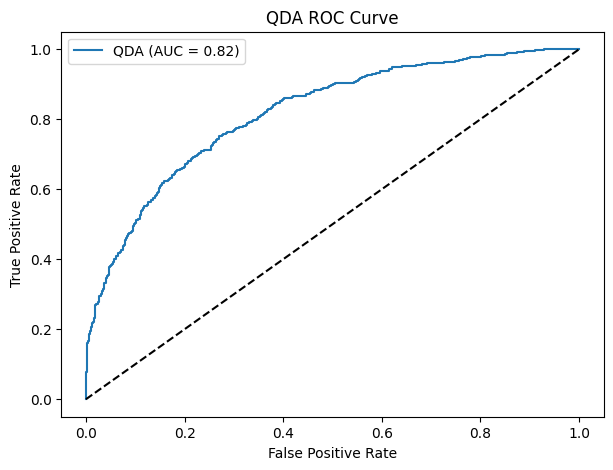

In [42]:
y_prob_qda = qda.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob_qda)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'QDA (AUC = {roc_auc:.2f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('QDA ROC Curve')
plt.legend()
plt.show()
